In [1]:
import numpy as np
from pyrootmemo import Parameter
from pyrootmemo.stats import GammaDistribution, GumbelDistribution, WeibullDistribution, PowerDistribution

# Distribution fitting

`pyrootmemo.stats` can fit probability density functions to user data. Distributions are fitted by minimising the (weighted) loglikelihood $\log\mathcal L$:

$$ \text{minimise} \log\mathcal L = \sum_i w_i p(x_i) $$

where $p(x_i)$ is the probability density for each observation $x_i$, and $w_i$ the weighting of this observations (by default equal to one, i.e. all observations are equally important).

The following distributions are included:

* Gamma (function `GammaDistribution()`)
* Gumbel (function `GumbelDistribution()`)
* Power (function `PowerDistribution()`)
* Weibull (function `WeibullDistribution()`)

Examples are presented below. 

First, create some data using the `Parameter` constructor. Data can have dimensions (e.g. megapascals). All fitted distribution parameters respect this dimensionality.

In [2]:
x = Parameter(2 + 8 * np.random.rand(100), 'MPa')

## Gamma distribution

The gamma distribution is described by a shape parameter $\kappa$ and a scale parameter $\lambda$. It's probability density function is:

$$ p(x) = \begin{cases}
\frac{x^{\kappa - 1}}{\Gamma(\kappa) \lambda^\kappa} \exp\left(-\frac{x}{\lambda}\right) & \text{when } x \geq 0 \\
0 & \text{else}
\end{cases} $$

where $\Gamma\left(\cdot\right)$ is the gamma function.

First, create the fit object.

In [3]:
gamma_fit = GammaDistribution(x)

The fitted scale and shape parameters of the gamma distribution can be queried by calling the fit attributes

In [4]:
print(gamma_fit.scale)
print(gamma_fit.shape)

1.0153920183544847 megapascal
5.75552111598128


For all distributions, the `weights` parameter can be used to set individual weightings to each data points. Weights must be dimensionless.
For example, the following sets weights as proportional to the (dimensionless) input data. Note that best-fitting distribution changes!

In [5]:
gamma_fit_weighted = GammaDistribution(x, weights = x.value)
print(gamma_fit_weighted.scale)
print(gamma_fit_weighted.shape)

0.8703961640446819 megapascal
7.780746761295815


## Gumbel distribution

The Gumbel distribution is described by a location parameter $\mu$ and a scale parameter $\lambda$. It's probability density function is:

$$ p(x) = \frac{1}{\lambda} \exp\left[-\left(z + \exp\left(-z\right)\right)\right] $$

where:

$$ z = \frac{x - \mu}{\lambda} $$

First, create the fit object.


In [6]:
gumbel_fit = GumbelDistribution(x)

The fitted scale and shape parameters of the gamma distribution can be queried by calling the fit attributes

In [7]:
print(gumbel_fit.location)
print(gumbel_fit.scale)

4.705322654035844 megapascal
2.0265013054480336 megapascal


## Power distribution

The power distribution is described by a power exponent $\beta$ and a lower and upper limit for $x$ (0 < $x_{min}$ < $x_{max}$). It's probability density function is:

$$ p(x) = \begin{cases}
\alpha \left(\frac{x}{x_0}\right)^\beta & \text{when } x_{min} \leq x \leq x_{max} \\
0 & \text{else}
\end{cases} $$

$where $x_0$ is a reference value, set to one unit of $x$ if not otherwise specified. The multiplier $\alpha$ follows from:

$$ \frac{1}{\alpha} = \int \limits_{x=x_{min}}^{x_{max}} p(x) ~d x $$

First, create the fit object.

In [8]:
power_fit = PowerDistribution(x)

The best-fitting values of $x_{min}$ and $x_{min}$ are always the lower and upper limit of the $x$-data, but if needed they can be defined explicitly:

In [9]:
power_fit_2 = PowerDistribution(x, lower = Parameter(1, 'MPa'), upper = Parameter(11, 'MPa'))

Fiited values can be queried by calling the attributes of the fit object:

In [10]:
print(power_fit.lower)
print(power_fit.upper)
print(power_fit.exponent)

2.0768638495408593 megapascal
9.970558091902875 megapascal
-0.19533157360061962


If you want to check the assumed reference value $x_0$

In [11]:
print(power_fit.x0)

1.0 megapascal


The powerlaw multiplier can be calculated from the fitted results:

In [12]:
print(power_fit.calc_multiplier())

0.17638163829382372 / megapascal


## Weibull distribution

The Weibull distribution is described by a shape parameter $\kappa$ and a scale parameter $\lambda$. It's probability density function is:

$$ p(x) = \begin{cases}
\left(\frac{\kappa}{\lambda}\right) \left(\frac{x}{\lambda}\right)^{\kappa - 1}  \exp\left[-\left(\frac{x}{\lambda}\right)^{\kappa}\right] & \text{when } x > 0 \\ 
0 & \text{else}
\end{cases} $$

First, create the fit object.

In [13]:
weibull_fit = WeibullDistribution(x)

Fiited values can be queried by calling the attributes of the fit object:

In [14]:
print(weibull_fit.shape)
print(weibull_fit.scale)

2.767879185981194
6.588803592236532 megapascal


## Additional functionality

All distribution fitting classes have some additional functionality:

* Plot the fitted distribution and compare to input data

All distribution fitting classes have some additional functionality:

* Plot the fitted distribution and compare to input data

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='x [MPa]', ylabel='Probability density [1 / MPa]'>)

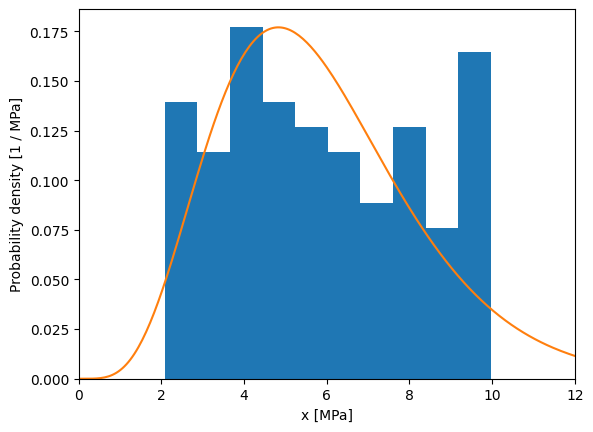

In [15]:
gamma_fit.plot()

* Calculate probability densities
* Calculate cumulative probability densities

In [16]:
print(gamma_fit.calc_density(Parameter(8, 'MPa')))
print(gamma_fit.calc_density(Parameter([0, 8, 10], 'MPa'), cumulative = True))

0.08597497701579157 / megapascal
[0.         0.82396844 0.93917458]


* Draw new samples from the fitted distribution. For example, to draw ten new random values

In [17]:
print(gamma_fit.generate_random(10))

[5.327222163865041 8.878882506486132 7.7019135936319065 4.279796967781288 5.652649369676634 6.27262036767086 5.471437687071941 7.130273977366053 8.393738057395312 5.133788465756023] megapascal
